# **Resolución Numérica de la Ecuación de Schrödinger: Del Pozo de Potencial a los Átomos Multielectrónicos**

**Autores:** [Tus Nombres]  
**Asignatura:** Métodos Numéricos y sus Aplicaciones a la Física  

---

## **Resumen**
En la presente práctica se aborda la resolución numérica de la ecuación de Schrödinger independiente del tiempo para sistemas de complejidad creciente. En primer lugar, se analiza un sistema unidimensional, el pozo de potencial finito, comparando una integración explícita por disparo con el algoritmo de Numerov. Posteriormente, se extiende el formalismo a tres dimensiones para resolver potenciales con simetría esférica, analizando el átomo de hidrógeno, el ión helio ($He^+$) y el electrón de valencia del litio mediante un modelo de apantallamiento. Se discuten los retos propios del análisis numérico cuántico, como el crecimiento exponencial del error en la zona clásicamente prohibida, la estabilización del método de disparo y la necesidad física de ajustar el dominio de integración espacial.

---

## **Introducción teórica y pozo de potencial finito (1D)**

La ecuación de Schrödinger describe la evolución temporal y espacial de una partícula masiva no relativista. Para sistemas donde el potencial $V$ no depende del tiempo, la función de onda se puede factorizar, conduciendo a la ecuación de Schrödinger independiente del tiempo:
$$-\frac{\hbar^2}{2m}\frac{d^2\psi(x)}{dx^2} + V(x)\psi(x) = E\psi(x)$$

El objetivo principal de la física computacional en este ámbito es encontrar los autovalores de energía permitidos ($E_n$) y sus correspondientes autofunciones ($\psi_n$) para los estados ligados del sistema. Reordenando la ecuación, obtenemos una ecuación diferencial de segundo orden homogénea:
$$\frac{d^2\psi(x)}{dx^2} = \frac{2m}{\hbar^2}(V(x) - E)\psi(x)$$

Consideramos primero una partícula confinada en un pozo de potencial de anchura $a$ y profundidad $V_0$. El potencial se define como:
$$V(x) = \begin{cases} V_0 & \text{si } |x| > a/2 \\ 0 & \text{si } |x| < a/2 \end{cases}$$

Para facilitar el tratamiento numérico en el ordenador y evitar el manejo de constantes muy pequeñas, aplicamos un cambio de escala definiendo la variable adimensional $u = x/a$. Aplicando la regla de la cadena, la derivada se transforma en $\frac{d}{dx} = \frac{1}{a}\frac{d}{du}$. Sustituyendo en la ecuación original:
$$\frac{d^2\psi(u)}{du^2} = \frac{2ma^2}{\hbar^2}[V(u) - E]\psi(u)$$

A continuación, definimos una constante adimensional del sistema $k = \frac{2ma^2V_0}{\hbar^2}$ y parametrizamos la energía en función de la profundidad del pozo como $\alpha = E/V_0$. Con estas definiciones, la ecuación se reduce a una forma compacta computable:
$$\psi''(u) = C(u)\psi(u)$$
Donde $C(u)$ encapsula la física del problema de forma discreta:
$$C(u) = \begin{cases} -k\alpha & \text{si } |u| < 0.5 \text{ (interior del pozo)} \\ k(1-\alpha) & \text{si } |u| > 0.5 \text{ (exterior del pozo)} \end{cases}$$

Para este estudio, los parámetros físicos del pozo son $V_0 = 244$ eV y $a = 1 \times 10^{-10}$ m (1 Å).

## **Reducción radial para potenciales centrales (3D)**

Para sistemas atómicos, el potencial es central, es decir, $V = V(\vec{r}) = V(r)$. Esto permite factorizar la función de onda en una parte angular, descrita por los armónicos esféricos $Y_L^{m_l}$, y una parte puramente radial $R_{n,L}(r)$. Si definimos una nueva función $U(r) = r\,R(r)$, la ecuación de Schrödinger se simplifica a un problema equivalente unidimensional:
$$\frac{d^2 U(r)}{dr^2} = \frac{2m}{\hbar^2}\left[\frac{L(L+1)\hbar^2}{2mr^2} + V(r) - E\right]U(r)$$

El término $\frac{L(L+1)\hbar^2}{2mr^2}$ actúa como un potencial repulsivo adicional conocido como **barrera centrífuga**, que impide que electrones con momento angular $L > 0$ se acerquen al núcleo de forma abrupta.

Para el cálculo computacional, utilizamos el sistema de unidades atómicas ($\hbar = 1$, $m_e = 1$, $e = 1$), donde la distancia se mide en radios de Bohr ($a_0$) y la energía en Hartrees (1 Ha $\approx$ 27.211 eV). Con este sistema, la ecuación a integrar toma la forma ideal para el método de Numerov $U''(r) = f(r)U(r)$, con:
$$f(r) = \frac{L(L+1)}{r^2} + 2(V(r) - E)$$

## **Modelos de potencial atómico**

1. **Hidrógeno ($Z=1$) y helio iónico ($Z=2$):** al poseer un único electrón, el potencial es puramente coulombiano y no presenta apantallamiento: $V(r) = -Z/r$.
2. **Átomo de litio (electrón de valencia):** el litio neutro posee tres electrones. Modelamos el electrón más externo asumiendo que los dos electrones internos están confinados en una esfera rígida de radio $r = 1\,a_0$ (el *core* atómico). Para $r < 1\,a_0$ (zona de alta penetración), el electrón de valencia siente la carga nuclear total no apantallada: $V_{int} = -3/r + \Delta V$. Para $r > 1\,a_0$, los dos electrones internos apantallan el núcleo de forma perfecta, por lo que el electrón siente un potencial hidrogenoide: $V_{ext} = -1/r$. Imponiendo la continuidad del potencial en la frontera de las capas ($r=1$), deducimos que $\Delta V = 2$, quedando la región interna definida analíticamente como $V_{int} = -\frac{3}{r} + 2$.

## **Metodología numérica y desafíos computacionales**

### **Diferencias finitas frente al método de Numerov**
El esquema numérico utilizado en el pozo de potencial combina una integración explícita por disparo para el método más simple y la formulación de Numerov para la versión de mayor precisión. Numerov está diseñado para ecuaciones diferenciales de la forma $y''(x) = f(x)y(x)$, sin derivadas de primer orden, y reduce el error de truncamiento hasta $\mathcal{O}(\Delta x^6)$.

En la implementación, la relación de recurrencia se escribe directamente sobre la función de onda:
$$\psi_{k+1} = \frac{2\left(1 + \frac{5h^2 f_k}{12}\right)\psi_k - \left(1 - \frac{h^2 f_{k-1}}{12}\right)\psi_{k-1}}{1 - \frac{h^2 f_{k+1}}{12}}$$
Esto es lo que usa el código del solver de Numerov para propagar la solución de forma estable.

### **El método de disparo y la necesidad de divergencia**
Para que la solución matemática corresponda a un estado físico ligado, la función de onda debe anularse en el infinito ($\psi(\pm \infty) = 0$). El método de disparo consiste en integrar la ecuación desde el origen hacia fuera para una energía de prueba $E$. En general, si la energía no es un autovalor exacto, la cola de la función divergerá exponencialmente hacia $+\infty$ o $-\infty$.

Si encontramos dos energías para las cuales las divergencias asintóticas tienen signos opuestos, el **teorema de Bolzano** garantiza que existe un autovalor de energía válido entre ellas. Por tanto, la bisección necesita estrictamente que la función diverja para detectar el cruce por cero.

### **La paradoja de la integración y la solución del dominio dinámico**
Durante la ejecución surgieron dos problemas acoplados de naturaleza física y numérica:

**El problema del tamaño del dominio:** al imponer un límite de integración rígido, observamos que el algoritmo era incapaz de hallar estados excitados en átomos con colas radiales más extensas. Físicamente, un límite pequeño actúa como una caja confinante infinita que amputa la cola del orbital antes de que pueda decaer. Para solucionarlo, se emplean dominios dinámicos basados en la física del átomo: un $r_{max}$ mayor para el hidrógeno y menor para el helio iónico, coherente con su radio más compacto.

**El freno de divergencia de normalización:** aunque permitir que la solución numérica diverja es vital para que el método de bisección funcione, esa misma divergencia destruye la visualización de la probabilidad radial al normalizar ($\int |U|^2\,dr = 1$), pues un crecimiento espurio en la zona prohibida sesga la amplitud de la solución.

La solución implementada fue separar el motor matemático del motor gráfico:
1. Durante la integración, la función fluctúa libremente, garantizando una búsqueda de raíces estable.
2. Durante la extracción para visualización, se aplica un filtro físico para eliminar la cola numérica no fiable en la zona prohibida y obtener una densidad de probabilidad interpretable.

## **Implementación y resultados**


INICIANDO CÁLCULO DE ESTADOS LIGADOS:

    Progreso:█████████████████████████ 100%

ESTADOS LIGADOS: POZO DE POTENCIAL (Diferencias Finitas)
  n=01 | paridad=par   | E = 23.913685 eV
  n=02 | paridad=impar | E = 93.437940 eV
  n=03 | paridad=par   | E = 198.802265 eV

ESTADOS LIGADOS: POZO DE POTENCIAL (Método de Numerov)
  n=01 | E = 23.932411 eV
  n=02 | E = 93.525786 eV
  n=03 | E = 198.994786 eV

ESTADOS LIGADOS: ÁTOMOS HIDROGENOIDES (Ha y eV)
  Hidrógeno (Z=1):
    n=01, l=0 (s) | E_num = -0.499778 Ha (-13.5996 eV) | E_ana = -0.500000 Ha
    n=02, l=0 (s) | E_num = -0.124972 Ha (-3.4007 eV) | E_ana = -0.125000 Ha
    n=03, l=0 (s) | E_num = -0.055415 Ha (-1.5079 eV) | E_ana = -0.055556 Ha
    n=02, l=1 (p) | E_num = -0.125000 Ha (-3.4014 eV) | E_ana = -0.125000 Ha
    n=03, l=1 (p) | E_num = -0.055471 Ha (-1.5095 eV) | E_ana = -0.055556 Ha

  Helio Iónico (Z=2):
    n=01, l=0 (s) | E_num = -1.998047 Ha (-54.3696 eV) | E_ana = -2.000000 Ha
    n=02, l=0 (s) | E_num = -0.499756 Ha 

/tmp/ipykernel_172291/3593658801.py:573: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[1, col].legend(fontsize='small')


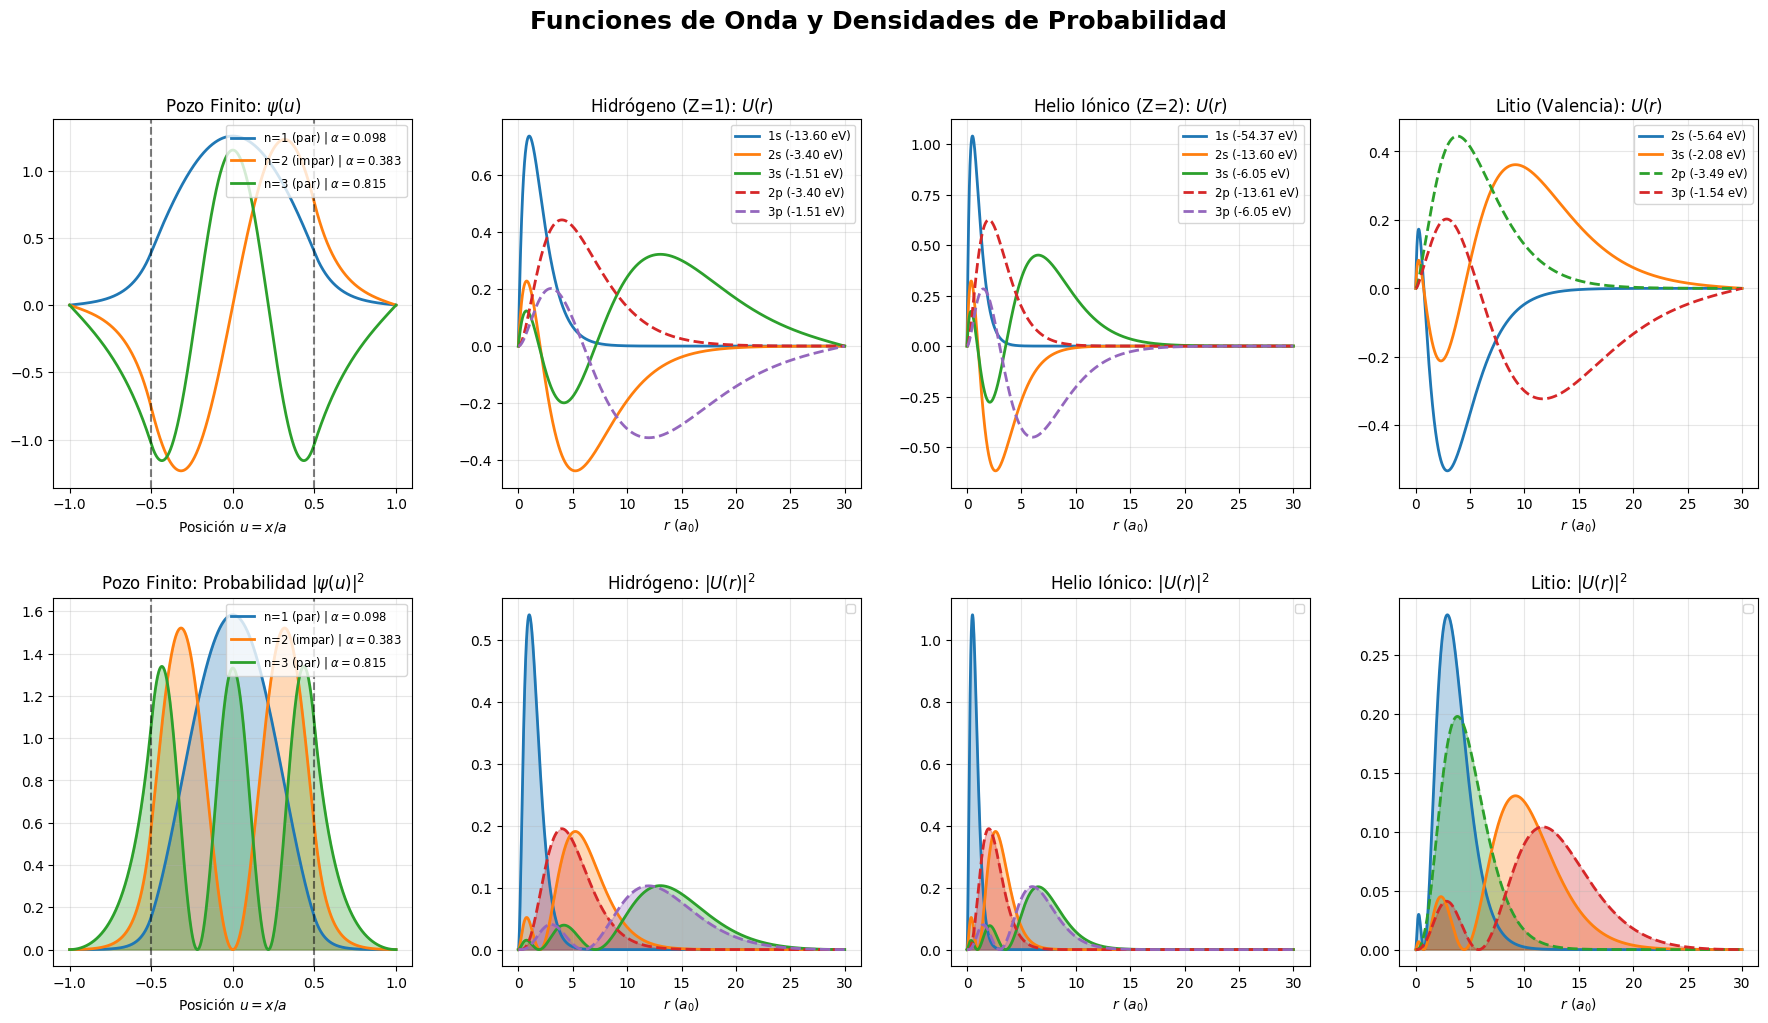


 VERIFICACIÓN DE NORMALIZACIÓN: Integral de |U(r)|^2 o |ψ(u)|^2
Sistema / Estado                         | Integral    
-----------------------------------------------------------------
Pozo n=1 (par)                           | 1.0000000000
Pozo n=2 (impar)                         | 1.0000000000
Pozo n=3 (par)                           | 1.0000000000
Hidrógeno n=1, l=0 (s)                   | 1.0000000000
Hidrógeno n=2, l=0 (s)                   | 1.0000000000
Hidrógeno n=3, l=0 (s)                   | 1.0000000000
Hidrógeno n=2, l=1 (p)                   | 1.0000000000
Hidrógeno n=3, l=1 (p)                   | 1.0000000000
Helio n=1, l=0 (s)                       | 1.0000000000
Helio n=2, l=0 (s)                       | 1.0000000000
Helio n=3, l=0 (s)                       | 1.0000000000
Helio n=2, l=1 (p)                       | 1.0000000000
Helio n=3, l=1 (p)                       | 1.0000000000
Litio n=2, l=0 (s)                       | 1.0000000000
Litio n=3, l=0 (s)           

In [5]:
import numpy as np
import matplotlib.pyplot as plt


# ==============================================================================
# SOLVER DEL POZO DE POTENCIAL FINITO MEDIANTE INTEGRACION EXPLICITA
# ==============================================================================
class PozoPotencialSolver:
    """Resuelve el pozo de potencial finito mediante un esquema de disparo explícito.

    La clase integra la ecuación adimensional del pozo en una malla unidimensional,
    busca cambios de signo en el valor de borde y refina los autovalores con bisección.
    """

    def __init__(
        self,
        V0=244,
        a=1e-10,
        c=299792458,
        hbar=6.582e-16,
        n=4001,
        umax=4,
    ):
        # Parametros fisicos del problema.
        self.V0 = V0
        self.a = a
        self.c = c
        self.hbar = hbar
        self.n = n
        self.umax = umax

        # Conversion a una masa electronica efectiva en las unidades usadas en el codigo.
        self.m = 0.511e6 / (self.c ** 2)
        # Constante adimensional del pozo.
        self.k = 2 * self.m * (self.a ** 2) * self.V0 / (self.hbar ** 2)
        # Estimacion inicial para el barrido de autovalores.
        self.alpha0 = np.pi ** 2 / self.k
        self.alpha_inicial_scan = 0.5 * self.alpha0

        # Mallado adimensional en el intervalo [0, 1].
        self.u = np.linspace(0, self.umax, self.n) / self.umax
        self.du = self.u[1] - self.u[0]

    def C(self, punto, alpha):
        # Coeficiente de la ecuacion diferencial en interior y exterior del pozo.
        if np.abs(punto) < 0.5:
            return -self.k * alpha
        return self.k * (1 - alpha)

    def psi_dif(self, alpha, paridad="par"):
        # Integracion por disparo con condiciones iniciales impuestas por la paridad.
        psi, dpsi = (np.zeros(self.n), np.zeros(self.n))

        if paridad == "par":
            psi[0] = 1
            dpsi[0] = 0
        elif paridad == "impar":
            psi[0] = 0
            dpsi[0] = 1
        else:
            raise ValueError("La paridad debe ser 'par' o 'impar'.")

        # Propagacion Euleriana simple para evaluar el borde de cada energia de prueba.
        for i in range(0, self.n - 1):
            psi[i + 1] = psi[i] + dpsi[i] * self.du
            dpsi[i + 1] = dpsi[i] + self.C(self.u[i], alpha) * psi[i] * self.du

        return psi
    
    def _valor_borde(self, alpha, paridad):
        # Devuelve el valor en el borde para usarlo como funcion objetivo en la biseccion.
        return self.psi_dif(alpha, paridad)[-1]

    def buscar_intervalos_autovalores(self, paridad="par", paso=1e-3):
        # Barrido de energias para localizar cambios de signo.
        a = max(0.0, self.alpha_inicial_scan)
        b = a + paso
        psia = self._valor_borde(a, paridad)
        intervalos = []

        while b <= 1:
            psib = self._valor_borde(b, paridad)
            if psia * psib < 0:
                intervalos.append((a, b))
            a = b
            b = a + paso
            psia = psib

        return intervalos

    def refinar_autovalor_biseccion(self, intervalo, paridad="par", tol=1e-8, max_iter=200):
        # Refinamiento del autovalor usando biseccion sobre el valor del borde.
        a, b = intervalo
        fa = self._valor_borde(a, paridad)
        fb = self._valor_borde(b, paridad)

        if fa * fb > 0:
            raise ValueError("El intervalo no encierra una raiz.")

        for _ in range(max_iter):
            c = 0.5 * (a + b)
            fc = self._valor_borde(c, paridad)

            if abs(fc) < tol or abs(b - a) < tol:
                return c
            if fa * fc < 0:
                b, fb = c, fc
            else:
                a, fa = c, fc

        return 0.5 * (a + b)

    def encontrar_autovalores(self, paridad="par", paso_scan=1e-3, tol_biseccion=1e-8):
        # Combina el barrido inicial y la biseccion para devolver todos los autovalores encontrados.
        intervalos = self.buscar_intervalos_autovalores(paridad=paridad, paso=paso_scan)
        return [self.refinar_autovalor_biseccion(itv, paridad=paridad, tol=tol_biseccion) for itv in intervalos]

    def onda_completa(self, alpha, paridad="par"):
        # Calcula la solucion en el semieje positivo.
        psi_pos = self.psi_dif(alpha, paridad)
        u_pos = self.u

        # Impone simetria par o impar para reconstruir toda la funcion de onda.
        if paridad == "par":
            psi_neg = psi_pos[1:][::-1]
        elif paridad == "impar":
            psi_neg = -psi_pos[1:][::-1]

        u_neg = -u_pos[1:][::-1]
        u_full = np.concatenate([u_neg, u_pos])
        psi_full = np.concatenate([psi_neg, psi_pos])

        # Normalizacion por la integral y no por el maximo, para obtener una densidad fisica.
        norma = np.sqrt(np.trapezoid(psi_full**2, u_full))
        if norma > 0:
            psi_full = psi_full / norma

        return u_full, psi_full

    def resolver_estados_ligados(self, paso_scan=1e-3, tol_biseccion=1e-8):
        # Resuelve todos los estados ligados que encuentre para ambas paridades.
        pares = self.encontrar_autovalores("par", paso_scan=paso_scan, tol_biseccion=tol_biseccion)
        impares = self.encontrar_autovalores("impar", paso_scan=paso_scan, tol_biseccion=tol_biseccion)

        estados = []
        for alpha in pares:
            estados.append({"paridad": "par", "alpha": alpha, "E_eV": alpha * self.V0})
        for alpha in impares:
            estados.append({"paridad": "impar", "alpha": alpha, "E_eV": alpha * self.V0})

        estados.sort(key=lambda x: x["alpha"])
        return estados


# ==============================================================================
# SOLVER DEL POZO DE POTENCIAL FINITO MEDIANTE NUMEROV
# ==============================================================================
class NumerovPozoSolver:
    """Resuelve el pozo de potencial finito usando la recurrencia de Numerov.

    La clase busca autovalores por cambios de signo en el borde y reconstruye la
    solución completa en un dominio simétrico para poder representarla.
    """

    def __init__(self, V0=244, a=1e-10, c=299792458, hbar=6.582e-16, n=4001, umax=4):
        # Parametros fisicos y discretizacion del dominio.
        self.V0 = V0
        self.a = a
        self.c = c
        self.hbar = hbar
        self.n = n
        self.umax = umax

        self.m = 0.511e6 / (self.c ** 2)
        self.k = 2 * self.m * (self.a ** 2) * self.V0 / (self.hbar ** 2)
        self.alpha0 = np.pi ** 2 / self.k
        self.alpha_inicial_scan = 0.5 * self.alpha0

        # Mallado simetrico alrededor del origen para reconstruir la solucion completa.
        self.u = np.linspace(-self.umax, self.umax, self.n) / self.umax
        self.du = self.u[1] - self.u[0]

    def C(self, punto, alpha):
        # Coeficiente local del pozo en funcion de la posicion.
        if np.abs(punto) < 0.5:
            return -self.k * alpha
        return self.k * (1 - alpha)

    def psi_numerov(self, alpha):
        # Integracion de la ecuacion de segundo orden mediante la recurrencia de Numerov.
        psi = np.zeros(self.n)
        f = np.array([self.C(ui, alpha) for ui in self.u])
        h2 = self.du ** 2

        # Condiciones iniciales de arranque para propagar la malla.
        psi[0] = 0.0
        psi[1] = 1e-12

        for i in range(1, self.n - 1):
            # Forma estandar de Numerov para y'' = f(x) y.
            a = 1 - (h2 * f[i + 1] / 12.0)
            b = (2 - ((2 * h2 * f[i]) / 12.0) + (h2 * f[i])) * psi[i]
            c = (1 - h2 * f[i - 1] / 12.0) * psi[i - 1]
            psi[i + 1] = (b - c) / a

        return psi

    def _valor_borde(self, alpha):
        # Valor objetivo para localizar cambios de signo.
        return self.psi_numerov(alpha)[-1]

    def buscar_intervalos_autovalores(self, paso=1e-3):
        # Localiza intervalos donde la funcion del borde cambia de signo.
        a = max(0.0, self.alpha_inicial_scan)
        b = a + paso
        fa = self._valor_borde(a)
        intervalos = []

        while b <= 1:
            fb = self._valor_borde(b)
            if fa * fb < 0:
                intervalos.append((a, b))
            a, fa = b, fb
            b = a + paso

        return intervalos

    def refinar_autovalor_biseccion(self, intervalo, tol=1e-10, max_iter=300):
        # Refina cada autovalor con biseccion.
        a, b = intervalo
        fa = self._valor_borde(a)
        fb = self._valor_borde(b)

        if fa * fb > 0:
            raise ValueError("El intervalo no encierra una raiz.")

        for _ in range(max_iter):
            c = 0.5 * (a + b)
            fc = self._valor_borde(c)
            if abs(fc) < tol or abs(b - a) < tol:
                return c
            if fa * fc < 0:
                b, fb = c, fc
            else:
                a, fa = c, fc

        return 0.5 * (a + b)

    def resolver_estados_ligados(self, paso_scan=1e-3, tol_biseccion=1e-10):
        # Devuelve la lista de autovalores energeticos encontrados.
        intervalos = self.buscar_intervalos_autovalores(paso=paso_scan)
        alphas = [self.refinar_autovalor_biseccion(itv, tol=tol_biseccion) for itv in intervalos]
        return [{"alpha": alpha, "E_eV": alpha * self.V0} for alpha in alphas]


# ==============================================================================
# SOLVER RADIAL PARA SISTEMAS ATOMICOS CON POTENCIAL CENTRAL
# ==============================================================================
class NumerovAtomSolver:
    """Resuelve la ecuacion radial para sistemas atomicos con potencial central.

    Implementa un esquema de Numerov sobre una malla radial y permite tratar
    potenciales hidrogenoides y un modelo efectivo de litio por tramos.
    """

    HARTREE_TO_EV = 27.211386245988

    def __init__(self, r_min=1e-4, r_max=30.0, n=15000):
        # Mallado radial y paso de integracion.
        self.r_min = r_min
        self.r_max = r_max
        self.n = n
        self.r = np.linspace(r_min, r_max, n)
        self.h = self.r[1] - self.r[0]

    def _potencial_hidrogenoide(self, r, Z=1):
        # Potencial coulombiano para atomos de un electron.
        return -Z / r

    def _potencial_litio_efectivo(self, r):
        # Potencial por tramos para el electron de valencia del litio.
        if r < 1.0:
            return -3.0 / r + 2.0
        return -1.0 / r

    def _f_radial(self, r, E, l, tipo="hidrogeno", Z=1):
        # Construye la funcion f(r) para la ecuacion U''(r) = f(r) U(r).
        if tipo in ("hidrogeno", "hidrogenoide"):
            V = self._potencial_hidrogenoide(r, Z=Z)
        elif tipo == "litio":
            V = self._potencial_litio_efectivo(r)
        else:
            raise ValueError("Tipo no valido: use 'hidrogeno', 'hidrogenoide' o 'litio'.")

        return l * (l + 1) / (r ** 2) + 2 * (V - E)

    def integrar_u(self, E, l=0, tipo="hidrogeno", Z=1):
        # Integra la funcion radial U(r) sobre la malla.
        u = np.zeros(self.n)
        f = np.array([self._f_radial(ri, E, l, tipo=tipo, Z=Z) for ri in self.r])
        h2 = self.h ** 2

        # Condiciones iniciales cerca del origen.
        u[0] = 0.0
        u[1] = 1e-5

        for i in range(1, self.n - 1):
            # Recurrencia de Numerov para la funcion radial.
            a = 1 - (h2 * f[i + 1] / 12.0)
            b = 2 * (1 + 5 * h2 * f[i] / 12.0) * u[i]
            c = (1 - h2 * f[i - 1] / 12.0) * u[i - 1]
            u[i + 1] = (b - c) / a
            
            # Limite de seguridad para evitar que una divergencia numerica arruine el calculo.
            if abs(u[i + 1]) > 1e6:
                u[i + 1:] = u[i + 1]
                break

        return u

    def _valor_borde(self, E, l=0, tipo="hidrogeno", Z=1):
        # Funcion objetivo para la busqueda de energias ligadas.
        return self.integrar_u(E, l=l, tipo=tipo, Z=Z)[-1]

    def buscar_intervalos_energia(self, E_min, E_max, paso_E, l=0, tipo="hidrogeno", Z=1):
        # Barrido energetico para detectar cambios de signo.
        E1 = E_min
        E2 = E1 + paso_E
        f1 = self._valor_borde(E1, l=l, tipo=tipo, Z=Z)
        intervalos = []

        while E2 <= E_max:
            f2 = self._valor_borde(E2, l=l, tipo=tipo, Z=Z)
            if f1 * f2 < 0:
                intervalos.append((E1, E2))
            E1, f1 = E2, f2
            E2 = E1 + paso_E

        return intervalos

    def refinar_energia_biseccion(self, intervalo, l=0, tipo="hidrogeno", Z=1, tol=1e-10, max_iter=300):
        # Biseccion para obtener la energia con mayor precision.
        a, b = intervalo
        fa = self._valor_borde(a, l=l, tipo=tipo, Z=Z)
        fb = self._valor_borde(b, l=l, tipo=tipo, Z=Z)

        if fa * fb > 0:
            raise ValueError("El intervalo no encierra una raiz.")

        for _ in range(max_iter):
            c = 0.5 * (a + b)
            fc = self._valor_borde(c, l=l, tipo=tipo, Z=Z)
            if abs(fc) < tol or abs(b - a) < tol:
                return c
            if fa * fc < 0:
                b, fb = c, fc
            else:
                a, fa = c, fc

        return 0.5 * (a + b)

    def encontrar_estados_ligados(self, n_estados=4, E_min=-1.2, E_max=-0.01, paso_E=2e-3, l=0, tipo="hidrogeno", Z=1):
        # Busca un numero concreto de energias ligadas dentro de un rango.
        intervalos = self.buscar_intervalos_energia(E_min, E_max, paso_E, l=l, tipo=tipo, Z=Z)
        energias = [self.refinar_energia_biseccion(itv, l=l, tipo=tipo, Z=Z) for itv in intervalos[:n_estados]]
        return energias

    def energia_analitica_hidrogenoide(self, n, Z=1):
        # Formula exacta de referencia para comparar resultados numericos.
        return -(Z ** 2) / (2 * n ** 2)

    def u_normalizada(self, E, l=0, tipo="hidrogeno", Z=1):
        # Integra y luego limpia la cola numerica para normalizar de manera fisica.
        u = self.integrar_u(E, l=l, tipo=tipo, Z=Z)
        f = np.array([self._f_radial(ri, E, l, tipo=tipo, Z=Z) for ri in self.r])
        
        # Identifica la region permitida, donde la solucion oscila.
        zonas_permitidas = np.where(f < 0)[0]
        if len(zonas_permitidas) > 0:
            ultimo_permitido = zonas_permitidas[-1]
        else:
            ultimo_permitido = 0
            
        # Si la solucion empieza a crecer en la zona prohibida, se descarta esa cola.
        for i in range(ultimo_permitido, self.n - 1):
            if abs(u[i + 1]) > abs(u[i]):
                u[i + 1:] = 0.0
                break
        
        # Normalizacion final sobre la malla radial.
        norm = np.sqrt(np.trapezoid(u ** 2, self.r))
        if norm > 0:
            u = u / norm
        return u

    def R_normalizada(self, E, l=0, tipo="hidrogeno", Z=1):
        # Convierte la funcion auxiliar U(r) en la radial R(r).
        u = self.u_normalizada(E, l=l, tipo=tipo, Z=Z)
        R = u / self.r
        return R


if __name__ == "__main__":
    # Oculta el cursor mientras se imprimen los resultados.
    print("\033[?25l", end="", flush=True)
    print("\n\033[1m" + "INICIANDO CÁLCULO DE ESTADOS LIGADOS:" + "\033[0m\n")
    
    # --------------------------------------------------------------------------
    # CAlculo de estados ligados en el pozo de potencial con ambos solvers.
    # --------------------------------------------------------------------------
    print("    Progreso:------------------------- 0%", end="\r", flush=True)
    solver_p = PozoPotencialSolver()
    est_pozo = solver_p.resolver_estados_ligados()
    
    print("    Progreso:\033[32m" + "█████" + "\033[0m" + "-------------------- 20%", end="\r", flush=True)
    solver_num = NumerovPozoSolver()
    est_pozo_num = solver_num.resolver_estados_ligados()
    
    # --------------------------------------------------------------------------
    # Calculo de estados atomicos hidrogenoides.
    # --------------------------------------------------------------------------
    print("    Progreso:\033[32m" + "██████████" + "\033[0m" + "--------------- 40%", end="\r", flush=True)
    atom_solver = NumerovAtomSolver(r_max=30, n=3500)
    E_H_s = atom_solver.encontrar_estados_ligados(n_estados=3, E_min=-1.2, E_max=-0.02, l=0, tipo="hidrogeno")
    E_H_p = atom_solver.encontrar_estados_ligados(n_estados=2, E_min=-0.2, E_max=-0.02, l=1, tipo="hidrogeno")
    
    print("    Progreso:\033[32m" + "███████████████" + "\033[0m" + "---------- 60%", end="\r", flush=True)
    E_He_s = atom_solver.encontrar_estados_ligados(n_estados=3, E_min=-4.9, E_max=-0.05, paso_E=5e-3, l=0, tipo="hidrogenoide", Z=2)
    E_He_p = atom_solver.encontrar_estados_ligados(n_estados=2, E_min=-1.5, E_max=-0.05, paso_E=5e-3, l=1, tipo="hidrogenoide", Z=2)
    
    # --------------------------------------------------------------------------
    # Calculo del litio efectivo con potencial apantallado por tramos.
    # --------------------------------------------------------------------------
    print("    Progreso:\033[32m" + "████████████████████" + "\033[0m" + "----- 80%", end="\r", flush=True)
    E_Li_s = atom_solver.encontrar_estados_ligados(n_estados=2, E_min=-0.6, E_max=-0.02, paso_E=1e-3, l=0, tipo="litio")
    E_Li_p = atom_solver.encontrar_estados_ligados(n_estados=2, E_min=-0.2, E_max=-0.02, l=1, tipo="litio")
    
    print("    Progreso:\033[32m" + "█████████████████████████" + "\033[0m" + " 100%", end="\n\n", flush=True)

    # --------------------------------------------------------------------------
    # Impresion resumida de todos los autovalores encontrados.
    # --------------------------------------------------------------------------
    print("\033[1m" + "ESTADOS LIGADOS: POZO DE POTENCIAL (Diferencias Finitas)" + "\033[0m")
    for i, est in enumerate(est_pozo, 1):
        print(f"  n={i:02d} | paridad={est['paridad']:5s} | E = {est['E_eV']:.6f} eV")

    print("\n\033[1m" + "ESTADOS LIGADOS: POZO DE POTENCIAL (Método de Numerov)" + "\033[0m")
    for i, est in enumerate(est_pozo_num, 1):
        print(f"  n={i:02d} | E = {est['E_eV']:.6f} eV")

    print("\n\033[1m" + "ESTADOS LIGADOS: ÁTOMOS HIDROGENOIDES (Ha y eV)" + "\033[0m")
    print("  Hidrógeno (Z=1):")
    for i, E in enumerate(E_H_s, 1):
        print(f"    n={i:02d}, l=0 (s) | E_num = {E:.6f} Ha ({E * atom_solver.HARTREE_TO_EV:.4f} eV) | E_ana = {atom_solver.energia_analitica_hidrogenoide(i, 1):.6f} Ha")
    for i, E in enumerate(E_H_p, 2):
        print(f"    n={i:02d}, l=1 (p) | E_num = {E:.6f} Ha ({E * atom_solver.HARTREE_TO_EV:.4f} eV) | E_ana = {atom_solver.energia_analitica_hidrogenoide(i, 1):.6f} Ha")
        
    print("\n  Helio Iónico (Z=2):")
    for i, E in enumerate(E_He_s, 1):
        print(f"    n={i:02d}, l=0 (s) | E_num = {E:.6f} Ha ({E * atom_solver.HARTREE_TO_EV:.4f} eV) | E_ana = {atom_solver.energia_analitica_hidrogenoide(i, 2):.6f} Ha")
    for i, E in enumerate(E_He_p, 2):
        print(f"    n={i:02d}, l=1 (p) | E_num = {E:.6f} Ha ({E * atom_solver.HARTREE_TO_EV:.4f} eV) | E_ana = {atom_solver.energia_analitica_hidrogenoide(i, 2):.6f} Ha")

    print("\n\033[1m" + "ESTADOS LIGADOS: LITIO EFECTIVO (Apantallado)" + "\033[0m")
    for i, E in enumerate(E_Li_s, 2):
        print(f"    n={i:02d}, l=0 (s) | E_num = {E:.6f} Ha ({E * atom_solver.HARTREE_TO_EV:.4f} eV)")
    for i, E in enumerate(E_Li_p, 2):
        print(f"    n={i:02d}, l=1 (p) | E_num = {E:.6f} Ha ({E * atom_solver.HARTREE_TO_EV:.4f} eV)")

    # Vuelve a mostrar el cursor al finalizar.
    print("\033[?25h", end="", flush=True)

    # ==============================================================================
    # GRAFICAS DE FUNCIONES DE ONDA Y PROBABILIDADES RADIALES
    # ==============================================================================
    # Matriz 2x4: fila superior para ondas y fila inferior para probabilidades.
    fig, axs = plt.subplots(2, 4, figsize=(22, 11))
    fig.suptitle("Funciones de Onda y Densidades de Probabilidad", fontsize=18, fontweight='bold')
    plt.subplots_adjust(hspace=0.3, wspace=0.25)

    # --------------------------------------------------------------------------
    # Columna 0: pozo finito.
    # --------------------------------------------------------------------------
    ax_pozo_psi = axs[0, 0]
    ax_pozo_prob = axs[1, 0]

    for i, est in enumerate(est_pozo, 1):
        # Obtiene la onda completa a partir de la energia y la paridad del estado.
        u_f, psi_f = solver_p.onda_completa(est['alpha'], est['paridad'])
        
        # Construye la etiqueta de la curva con informacion energetica.
        label_pozo = f"n={i} ({est['paridad']}) | $\\alpha={est['alpha']:.3f}$"
        
        # Dibuja la funcion de onda y captura el color para reutilizarlo en la probabilidad.
        line = ax_pozo_psi.plot(u_f, psi_f, label=label_pozo, lw=2)
        color = line[0].get_color()
        
        # Calcula y representa la densidad de probabilidad asociada.
        prob = psi_f**2
        ax_pozo_prob.plot(u_f, prob, label=label_pozo, color=color, lw=2)
        ax_pozo_prob.fill_between(u_f, 0, prob, color=color, alpha=0.3)

    for ax in [ax_pozo_psi, ax_pozo_prob]:
        # Marca los bordes del pozo para orientar la lectura de las graficas.
        ax.axvline(-0.5, color='k', linestyle='--', alpha=0.5)
        ax.axvline(0.5, color='k', linestyle='--', alpha=0.5)
        ax.set_xlabel(r"Posición $u = x/a$")
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize='small', loc='upper right')

    ax_pozo_psi.set_title(r"Pozo Finito: $\psi(u)$")
    ax_pozo_prob.set_title(r"Pozo Finito: Probabilidad $|\psi(u)|^2$")

    # --------------------------------------------------------------------------
    # Funcion auxiliar para graficar estados atomicos en forma homogena.
    # --------------------------------------------------------------------------
    def plot_atom(ax_psi, ax_prob, E_list, l_val, start_n, tipo, Z, r_lim, ls):
        # Extrae la malla radial global.
        r = atom_solver.r
        mask = r < r_lim
        r_plot = r[mask]
        l_str = 's' if l_val == 0 else 'p'
        
        for i, E in enumerate(E_list, start=start_n):
            # Normaliza y recorta la solucion para la region visible.
            u = atom_solver.u_normalizada(E, l=l_val, tipo=tipo, Z=Z)
            u_plot = u[mask]
            prob = u_plot**2
            
            # Construye una etiqueta con el estado y la energia en eV.
            E_eV = E * atom_solver.HARTREE_TO_EV
            label = f"{i}{l_str} ({E_eV:.2f} eV)"
            
            # Dibuja la funcion radial.
            line = ax_psi.plot(r_plot, u_plot, linestyle=ls, label=label, lw=2)
            color = line[0].get_color()
            
            # Dibuja la densidad de probabilidad con el mismo color.
            ax_prob.plot(r_plot, prob, linestyle=ls, color=color, lw=2)
            ax_prob.fill_between(r_plot, 0, prob, color=color, alpha=0.3)

    # --------------------------------------------------------------------------
    # Columna 1: hidrogeno.
    # --------------------------------------------------------------------------
    plot_atom(axs[0, 1], axs[1, 1], E_H_s, 0, 1, "hidrogeno", 1, 30, ls='-')
    plot_atom(axs[0, 1], axs[1, 1], E_H_p, 1, 2, "hidrogeno", 1, 30, ls='--')
    axs[0, 1].set_title(r"Hidrógeno (Z=1): $U(r)$")
    axs[1, 1].set_title(r"Hidrógeno: $|U(r)|^2$")

    # --------------------------------------------------------------------------
    # Columna 2: helio ionico.
    # --------------------------------------------------------------------------
    plot_atom(axs[0, 2], axs[1, 2], E_He_s, 0, 1, "hidrogenoide", 2, 30, ls='-')
    plot_atom(axs[0, 2], axs[1, 2], E_He_p, 1, 2, "hidrogenoide", 2, 30, ls='--')
    axs[0, 2].set_title(r"Helio Iónico (Z=2): $U(r)$")
    axs[1, 2].set_title(r"Helio Iónico: $|U(r)|^2$")

    # --------------------------------------------------------------------------
    # Columna 3: litio efectivo.
    # --------------------------------------------------------------------------
    plot_atom(axs[0, 3], axs[1, 3], E_Li_s, 0, 2, "litio", 1, 40, ls='-')
    plot_atom(axs[0, 3], axs[1, 3], E_Li_p, 1, 2, "litio", 1, 40, ls='--')
    axs[0, 3].set_title(r"Litio (Valencia): $U(r)$")
    axs[1, 3].set_title(r"Litio: $|U(r)|^2$")

    # Formato comun para las columnas atomicas.
    for col in range(1, 4):
        axs[0, col].set_xlabel(r"$r$ ($a_0$)")
        axs[1, col].set_xlabel(r"$r$ ($a_0$)")
        axs[0, col].grid(True, alpha=0.3)
        axs[1, col].grid(True, alpha=0.3)
        axs[0, col].legend(fontsize='small')
        axs[1, col].legend(fontsize='small')

    plt.show()

    # ==============================================================================
    # VERIFICACION DE NORMALIZACION DE LAS FUNCIONES
    # ==============================================================================
    print("\n" + "=" * 65)
    print("\033[1m" + " VERIFICACIÓN DE NORMALIZACIÓN: Integral de |U(r)|^2 o |ψ(u)|^2" + "\033[0m")
    print("=" * 65)
    print(f"{'Sistema / Estado':<40} | {'Integral':<12}")
    print("-" * 65)

    # Pozo de potencial: verifica la integral de la funcion de onda completa.
    for i, est in enumerate(est_pozo, 1):
        u_p, psi_p = solver_p.onda_completa(est['alpha'], est['paridad'])
        norm_val = np.trapezoid(psi_p**2, u_p)
        print(f"{f'Pozo n={i} ({est['paridad']})':<40} | {norm_val:.10f}")

    # Hidrogeno: estado s.
    for i, E in enumerate(E_H_s, 1):
        u = atom_solver.u_normalizada(E, l=0, tipo="hidrogeno")
        norm_val = np.trapezoid(u**2, atom_solver.r)
        print(f"{f'Hidrógeno n={i}, l=0 (s)':<40} | {norm_val:.10f}")
    
    # Hidrogeno: estado p.
    for i, E in enumerate(E_H_p, 2):
        u = atom_solver.u_normalizada(E, l=1, tipo="hidrogeno")
        norm_val = np.trapezoid(u**2, atom_solver.r)
        print(f"{f'Hidrógeno n={i}, l=1 (p)':<40} | {norm_val:.10f}")

    # Helio ionico: estados s.
    for i, E in enumerate(E_He_s, 1):
        u = atom_solver.u_normalizada(E, l=0, tipo="hidrogenoide", Z=2)
        norm_val = np.trapezoid(u**2, atom_solver.r)
        print(f"{f'Helio n={i}, l=0 (s)':<40} | {norm_val:.10f}")
        
    # Helio ionico: estados p.
    for i, E in enumerate(E_He_p, 2):
        u = atom_solver.u_normalizada(E, l=1, tipo="hidrogenoide", Z=2)
        norm_val = np.trapezoid(u**2, atom_solver.r)
        print(f"{f'Helio n={i}, l=1 (p)':<40} | {norm_val:.10f}")

    # Litio efectivo: estados s.
    for i, E in enumerate(E_Li_s, 2):
        u = atom_solver.u_normalizada(E, l=0, tipo="litio")
        norm_val = np.trapezoid(u**2, atom_solver.r)
        print(f"{f'Litio n={i}, l=0 (s)':<40} | {norm_val:.10f}")
        
    # Litio efectivo: estados p.
    for i, E in enumerate(E_Li_p, 2):
        u = atom_solver.u_normalizada(E, l=1, tipo="litio")
        norm_val = np.trapezoid(u**2, atom_solver.r)
        print(f"{f'Litio n={i}, l=1 (p)':<40} | {norm_val:.10f}")

    print("=" * 65)

## **Discusión de resultados finales**

### **Precisión del método de Numerov en el pozo de potencial**
Al comparar los autovalores devueltos por la integración explícita del pozo frente a la formulación de Numerov, se aprecia una convergencia más robusta en la segunda. La formulación de Numerov reduce fuertemente el error de truncamiento y estabiliza mejor la búsqueda por bisección. Las representaciones del pozo muestran la penetración asintótica de la función de onda en la región prohibida, siendo esta penetración de mayor alcance para las funciones más excitadas.

### **Topología nodal y barrera centrífuga en hidrógeno**
Los resultados computacionales extraídos para el hidrógeno muestran una correlación consistente con la solución analítica de referencia $E_n = -1/(2n^2)$ Ha. Al visualizar las gráficas de probabilidad, comprobamos la regla teórica de los nodos: el número de ceros radiales que presenta la función de onda viene dado por $n - L - 1$.

Especialmente ilustrativo es el efecto de la **barrera centrífuga** originado por el momento angular. Si comparamos los estados excitados de $n=3$, observamos cómo el estado $3s$ puede presentar densidad probabilística cercana al origen, mientras que el orbital $3p$ ($L=1$) queda fuertemente desplazado por la repulsión efectiva $\sim L(L+1)/r^2$.

### **Efectos de escala en el ión helio ($He^+$)**
Para el caso del helio monoelectrónico ($Z=2$), la ausencia de apantallamiento interno provoca que el núcleo ejerza una atracción electrostática más intensa. Esto se traduce en valores de energía aproximadamente cuatro veces más profundos que en hidrógeno, coherentes con la dependencia $\propto Z^2$. En los trazados, se aprecia una contracción espacial clara del átomo, con el radio característico del estado fundamental alrededor de $0.5\,a_0$.

### **El modelo de apantallamiento del litio y la ruptura de degeneración**
A diferencia del hidrógeno, donde la energía de los subniveles depende solo de $n$, el litio muestra la complejidad de los átomos multielectrónicos. Al implementar el potencial efectivo por tramos, el algoritmo diferencia los estados $s$ y $p$ del electrón de valencia y permite observar la pérdida de degeneración accidental.

La clave física se encuentra en el subnivel $2s$ ($L=0$), que puede penetrar parcialmente en el *core* y sentir una carga nuclear efectiva mayor. El estado $2p$, al ser repelido del origen por poseer $L=1$, se aloja en zonas exteriores y queda más apantallado. Esto explica por qué, en química, el llenado electrónico sigue primero el $2s$ y después el $2p$.

## **Conclusión**
La resolución numérica de la ecuación de Schrödinger mediante el acoplamiento del método de Numerov y un algoritmo de disparo constituye una estrategia muy precisa para estados ligados. Para estabilizar el análisis, fue imprescindible separar la integración cruda de las técnicas de representación, validando así principios físicos como la penetración de barrera, la barrera centrífuga y el apantallamiento electrónico.